In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_generation.fair_world import simulate_fair_world


from src.training.preprocessing import split_data, scale_data
from src.training.train_lr import train_logistic_regression
from src.training.train_mlp import (
    MLP,
    train_epoch,
    evaluate,
    train,
    plot,
    train_mlp_model
)

from src.metrics.fairness import (
    fairness_by_group,
    equal_opportunity_diff,
    equalized_odds_diff
)

import torch
device = "mps" if torch.backends.mps.is_available() else "cpu"
device


'mps'

In [2]:
df = simulate_fair_world(10000)
df.head()


,race,gender,age,glucose_measured,hba1c_measured,diabetes_label
0,0,1,43.894905,97.476314,5.271769,0
1,1,0,57.074594,88.800353,4.648198,0
2,0,0,44.060216,106.327865,5.475736,0
3,0,1,46.151095,88.891874,5.173375,0
4,0,0,60.911279,93.252115,5.131325,0


In [3]:
features = ["glucose_measured", "hba1c_measured", "age"]
target = "diabetes_label"

X_train, X_test, y_train, y_test = split_data(df, features, target)

X_train_s, X_test_s, scaler = scale_data(X_train, X_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Prevalence:", y_train.mean())


Train size: 8000
Test size: 2000
Prevalence: 0.207875


In [4]:
X_train_s, X_test_s, scaler = scale_data(X_train, X_test)


In [5]:
lr_results = train_logistic_regression(
    X_train_s, y_train,
    X_test_s, y_test
)

print("LR Accuracy:", lr_results["accuracy"])
print("LR AUC:", lr_results["AUROC"])


LR Accuracy: 0.9975
LR AUC: 0.9999697990364304


Epoch 1/20: train_loss=0.1212, train_acc=99.49, val_loss=0.0100, val_acc=99.75
Epoch 2/20: train_loss=0.0063, train_acc=99.84, val_loss=0.0062, val_acc=99.85
Epoch 3/20: train_loss=0.0042, train_acc=99.86, val_loss=0.0058, val_acc=99.85
Epoch 4/20: train_loss=0.0035, train_acc=99.86, val_loss=0.0055, val_acc=99.85
Epoch 5/20: train_loss=0.0031, train_acc=99.91, val_loss=0.0042, val_acc=99.85
Epoch 6/20: train_loss=0.0029, train_acc=99.88, val_loss=0.0046, val_acc=99.85
Epoch 7/20: train_loss=0.0028, train_acc=99.89, val_loss=0.0051, val_acc=99.85
Epoch 8/20: train_loss=0.0025, train_acc=99.91, val_loss=0.0055, val_acc=99.85
Epoch 9/20: train_loss=0.0024, train_acc=99.90, val_loss=0.0066, val_acc=99.85
Epoch 10/20: train_loss=0.0025, train_acc=99.91, val_loss=0.0057, val_acc=99.85
Epoch 11/20: train_loss=0.0022, train_acc=99.94, val_loss=0.0050, val_acc=99.85
Epoch 12/20: train_loss=0.0021, train_acc=99.94, val_loss=0.0052, val_acc=99.85
Epoch 13/20: train_loss=0.0020, train_acc=99.92, 

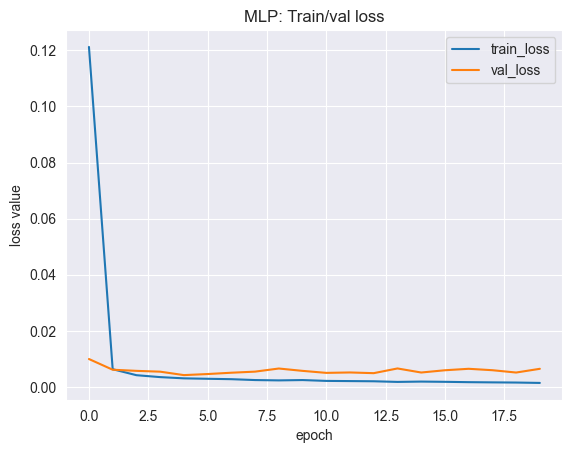

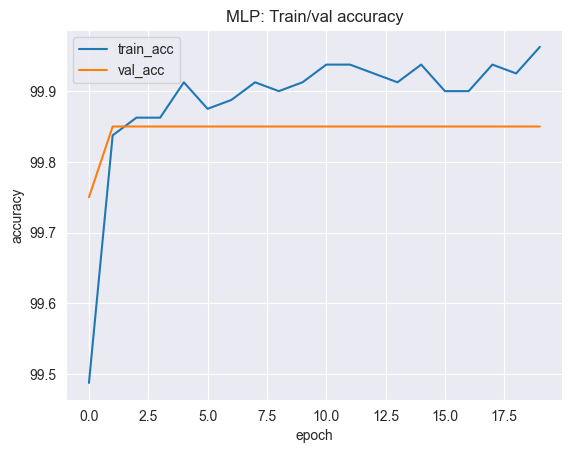

In [6]:
mlp_results = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=len(features),
    hidden_dim=32,
    n_epochs=20,
    lr=0.001
)

print("MLP Accuracy:", mlp_results["accuracy"])
print("MLP AUC:", mlp_results["AUROC"])


In [24]:
# --------------------------
# LR Fairness
# --------------------------
print("=== LR Fairness by Race ===")
lr_fair_race = fairness_by_group(y_test, lr_results["pred"], race_test)
print(lr_fair_race)

print("\n=== LR Fairness by Gender ===")
lr_fair_gender = fairness_by_group(y_test, lr_results["pred"], gender_test)
print(lr_fair_gender)

LR_EO_race   = equal_opportunity_diff(lr_fair_race)
LR_EO_gender = equal_opportunity_diff(lr_fair_gender)


# --------------------------
# MLP Fairness
# --------------------------
print("\n=== MLP Fairness by Race ===")
mlp_fair_race = fairness_by_group(y_test, mlp_results["pred"], race_test)
print(mlp_fair_race)

print("\n=== MLP Fairness by Gender ===")
mlp_fair_gender = fairness_by_group(y_test, mlp_results["pred"], gender_test)
print(mlp_fair_gender)

MLP_EO_race   = equal_opportunity_diff(mlp_fair_race)
MLP_EO_gender = equal_opportunity_diff(mlp_fair_gender)


=== LR Fairness by Race ===
   FPR       FNR       TPR  TNR
0  0.0  0.008475  0.991525  1.0
1  0.0  0.022472  0.977528  1.0
2  0.0  0.015152  0.984848  1.0

=== LR Fairness by Gender ===
   FPR       FNR       TPR  TNR
0  0.0  0.022346  0.977654  1.0
1  0.0  0.004717  0.995283  1.0

=== MLP Fairness by Race ===
   FPR       FNR       TPR  TNR
0  0.0  0.004237  0.995763  1.0
1  0.0  0.011236  0.988764  1.0
2  0.0  0.015152  0.984848  1.0

=== MLP Fairness by Gender ===
   FPR       FNR       TPR  TNR
0  0.0  0.011173  0.988827  1.0
1  0.0  0.004717  0.995283  1.0


In [23]:
results_fair = {
    "world_name": "Fair",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,
    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

results_fair


{'world_name': 'Fair',
 'LR_accuracy': 0.9975,
 'LR_AUROC': 0.9999697990364304,
 'LR_EO_race': 0.013997333841173187,
 'LR_EO_gender': 0.01762938758300825,
 'MLP_accuracy': np.float64(0.9985),
 'MLP_AUROC': 0.9999618514144384,
 'MLP_EO_race': 0.010914227015921929,
 'MLP_EO_gender': 0.0064562032254663615}